In [1]:
from dotenv import load_dotenv
import os
import boto3
import awswrangler as wr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

load_dotenv()

# ── Config ──────────────────────────────────────────────────────────
S3_OUTPUT = "s3://pharma-bi-raw/athena-results/"
DATABASE  = "pharma_bi_db"

session = boto3.Session(
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_DEFAULT_REGION")
)

def run_query(sql: str) -> pd.DataFrame:
    """Run an Athena SQL query and return a pandas DataFrame."""
    return wr.athena.read_sql_query(
        sql=sql,
        database=DATABASE,
        s3_output=S3_OUTPUT,
        boto3_session=session
    )

# ── Plot style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'font.family':       'sans-serif',
})

CATEGORY_COLORS = {
    'Prescription':   '#2C6FAC',
    'OTC':            '#3A9E6F',
    'Wellness':       '#E07B3A',
    'Personal Care':  '#9B5EA0',
    'Medical Devices':'#C0392B'
}

# ── Sanity check ────────────────────────────────────────────────────
df_check = run_query("SELECT COUNT(*) AS n FROM fact_sales")
print(f"Connection OK — {df_check['n'].iloc[0]:,} rows in FactSales")

Connection OK — 62,139 rows in FactSales


In [2]:
query_kpis = """
SELECT
    COUNT(salesid)                                          AS total_transactions,
    SUM(unitssold)                                          AS total_units_sold,
    ROUND(SUM(revenueeur), 2)                               AS total_revenue,
    ROUND(SUM(margineur), 2)                                AS total_margin,
    ROUND(SUM(margineur) / SUM(revenueeur) * 100, 1)        AS overall_margin_pct,
    ROUND(AVG(revenueeur), 2)                               AS avg_revenue_per_tx
FROM fact_sales
"""

df_kpis = run_query(query_kpis)
print("── Overall KPIs ──")
print(df_kpis.T.rename(columns={0: 'value'}).to_string())

── Overall KPIs ──
                         value
total_transactions       62139
total_units_sold        445793
total_revenue       8633977.31
total_margin        2421141.07
overall_margin_pct        28.0
avg_revenue_per_tx      138.95


In [3]:
query_category = """
SELECT
    dpr.category,
    COUNT(fs.salesid)                                                        AS transactions,
    SUM(fs.unitssold)                                                        AS total_units,
    ROUND(SUM(fs.revenueeur), 2)                                             AS total_revenue,
    ROUND(SUM(fs.margineur), 2)                                              AS total_margin,
    ROUND(AVG(fs.revenueeur), 2)                                             AS avg_revenue_per_tx,
    ROUND(AVG(fs.margineur), 2)                                              AS avg_margin_per_tx,
    ROUND(AVG(CAST(fs.unitssold AS DOUBLE)), 2)                              AS avg_units_per_tx,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1)                  AS margin_pct,
    ROUND(SUM(fs.revenueeur) / SUM(SUM(fs.revenueeur)) OVER () * 100, 1)    AS revenue_share_pct,
    ROUND(SUM(fs.revenueeur) / SUM(fs.unitssold), 2)                        AS revenue_per_unit
FROM fact_sales fs
JOIN dim_product dpr ON fs.productid = dpr.productid
GROUP BY dpr.category
ORDER BY total_revenue DESC
"""

df_cat = run_query(query_category)
print(df_cat.to_string(index=False))

       category  transactions  total_units  total_revenue  total_margin  avg_revenue_per_tx  avg_margin_per_tx  avg_units_per_tx  margin_pct  revenue_share_pct  revenue_per_unit
   Prescription         13120        63277     2797015.76     613166.39              213.19              46.74              4.82        21.9               32.4             44.20
            OTC         19412       177686     1797329.55     528166.03               92.59              27.21              9.15        29.4               20.8             10.12
       Wellness         12483        89423     1712456.88     575117.00              137.18              46.07              7.16        33.6               19.8             19.15
  Personal Care         11073       101510     1454603.15     486875.18              131.36              43.97              9.17        33.5               16.8             14.33
Medical Devices          6051        13897      872571.97     217816.47              144.20              36.00

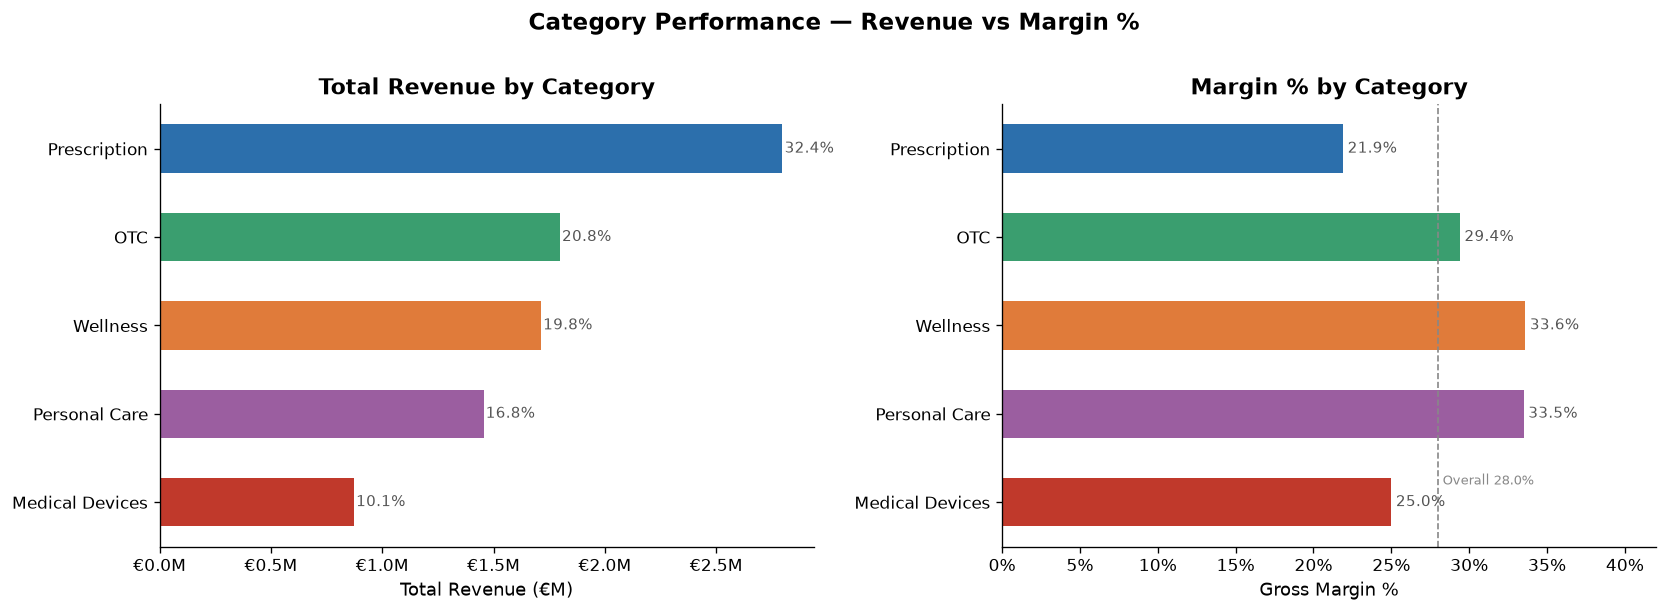

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_sorted = df_cat.sort_values('total_revenue')
colors = [CATEGORY_COLORS[c] for c in cat_sorted['category']]

# ── Chart 1: Total revenue by category ──────────────────────────────
bars = axes[0].barh(
    cat_sorted['category'],
    cat_sorted['total_revenue'] / 1e6,
    color=colors, height=0.55
)
axes[0].set_xlabel('Total Revenue (€M)')
axes[0].set_title('Total Revenue by Category')
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.1fM'))

for bar, share in zip(bars, cat_sorted['revenue_share_pct']):
    axes[0].text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{share}%', va='center', fontsize=9, color='#555'
    )

# ── Chart 2: Margin % by category ───────────────────────────────────
bars2 = axes[1].barh(
    cat_sorted['category'],
    cat_sorted['margin_pct'],
    color=colors, height=0.55
)
axes[1].set_xlabel('Gross Margin %')
axes[1].set_title('Margin % by Category')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
axes[1].set_xlim(0, 42)

for bar, pct in zip(bars2, cat_sorted['margin_pct']):
    axes[1].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%', va='center', fontsize=9, color='#555'
    )

# Overall margin reference line
axes[1].axvline(x=28.0, color='#888', linewidth=1, linestyle='--')
axes[1].text(28.3, 0.2, 'Overall 28.0%', fontsize=8, color='#888')

plt.suptitle('Category Performance — Revenue vs Margin %', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/01_category_revenue_margin.png', bbox_inches='tight')
plt.show()

In [6]:
query_brands = """
SELECT
    dpr.brand,
    dpr.category,
    COUNT(fs.salesid)                                                        AS transactions,
    ROUND(SUM(fs.revenueeur), 2)                                             AS total_revenue,
    ROUND(SUM(fs.margineur), 2)                                             AS total_margin,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1)                  AS margin_pct,
    ROUND(SUM(fs.revenueeur) / SUM(SUM(fs.revenueeur)) OVER () * 100, 1)    AS revenue_share_pct
FROM fact_sales fs
JOIN dim_product dpr ON fs.productid = dpr.productid
GROUP BY dpr.brand, dpr.category
ORDER BY total_revenue DESC
"""

df_brands = run_query(query_brands)
print("── Top 15 brands by revenue ──")
print(df_brands.head(15).to_string(index=False))


── Top 15 brands by revenue ──
      brand      category  transactions  total_revenue  total_margin  margin_pct  revenue_share_pct
   AntiBioX  Prescription          2935      726405.27     169919.75        23.4                8.4
  GlucoSafe  Prescription          2211      482885.75     105695.75        21.9                5.6
   NeuroMed  Prescription          1818      474936.83     101464.96        21.4                5.5
     DermRx  Prescription          2014      403308.53      86135.05        21.4                4.7
   PainLess           OTC          3689      392994.53     109221.15        27.8                4.6
 BioBalance      Wellness          2772      388566.68     127775.11        32.9                4.5
 ImmunoPlus      Wellness          2267      343443.34     115744.58        33.7                4.0
 EuroRelief           OTC          3288      319436.62     100982.88        31.6                3.7
SmileBright Personal Care          2960      318619.30     106101.78 

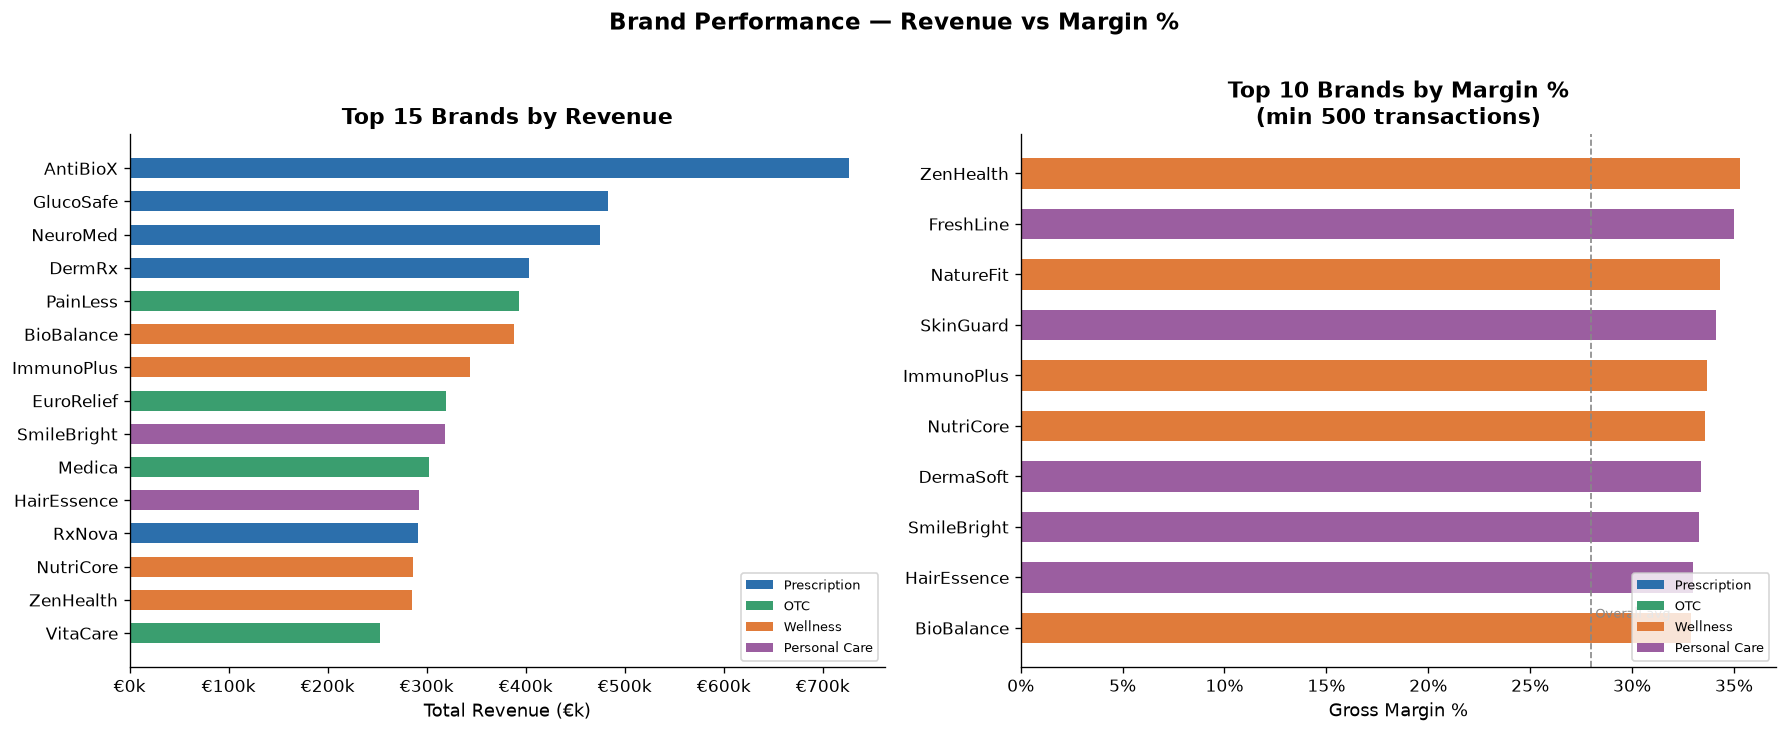

In [7]:
# ── Top 15 brands by revenue — coloured by category ─────────────────
top15 = df_brands.head(15).sort_values('total_revenue')
bar_colors = [CATEGORY_COLORS[c] for c in top15['category']]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars = axes[0].barh(
    top15['brand'],
    top15['total_revenue'] / 1e3,
    color=bar_colors, height=0.6
)
axes[0].set_xlabel('Total Revenue (€k)')
axes[0].set_title('Top 15 Brands by Revenue')
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))

legend_elements = [Patch(facecolor=v, label=k) for k, v in CATEGORY_COLORS.items()
                   if k in top15['category'].values]
axes[0].legend(handles=legend_elements, fontsize=8, loc='lower right')

# ── Top 10 brands by margin % (min 500 transactions) ────────────────
df_brands_margin = df_brands[df_brands['transactions'] >= 500].sort_values('margin_pct', ascending=False).head(10)
bar_colors2 = [CATEGORY_COLORS[c] for c in df_brands_margin.sort_values('margin_pct')['category']]

axes[1].barh(
    df_brands_margin.sort_values('margin_pct')['brand'],
    df_brands_margin.sort_values('margin_pct')['margin_pct'],
    color=bar_colors2, height=0.6
)
axes[1].set_xlabel('Gross Margin %')
axes[1].set_title('Top 10 Brands by Margin %\n(min 500 transactions)')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
axes[1].axvline(x=28.0, color='#888', linewidth=1, linestyle='--')
axes[1].text(28.2, 0.2, 'Overall avg', fontsize=8, color='#888')

axes[1].legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.suptitle('Brand Performance — Revenue vs Margin %', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/02_brand_performance.png', bbox_inches='tight')
plt.show()

In [15]:
query_cat_country = """
SELECT
    dp.country,
    dpr.category,
    ROUND(SUM(fs.revenueeur), 2)                            AS total_revenue,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1) AS margin_pct
FROM fact_sales fs
JOIN dim_product dpr  ON fs.productid  = dpr.productid
JOIN dim_pharmacy dp  ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.country, dpr.category
ORDER BY dp.country, total_revenue DESC
"""

df_cat_country = run_query(query_cat_country)

# Pivot for heatmap
pivot_rev = df_cat_country.pivot(index='country', columns='category', values='total_revenue').fillna(0)
pivot_rev = pivot_rev[['Prescription', 'OTC', 'Wellness', 'Personal Care', 'Medical Devices']]

print("── Revenue by category and country ──")
print(pivot_rev.round(0).to_string())



── Revenue by category and country ──
category     Prescription       OTC  Wellness  Personal Care  Medical Devices
country                                                                      
Austria          224789.0  141326.0  145003.0       109305.0          62858.0
Belgium          383658.0  267779.0  240626.0       227149.0         127298.0
France           467924.0  292988.0  275722.0       231652.0         138525.0
Germany          514066.0  325105.0  309058.0       261663.0         157742.0
Italy            420845.0  273651.0  267532.0       225918.0         144209.0
Netherlands      310782.0  195458.0  181744.0       163090.0          96674.0
Poland           227458.0  153535.0  146207.0       114671.0          72365.0
Spain            247495.0  147487.0  146564.0       121154.0          72901.0


── Revenue by category and country ──
category     Prescription       OTC  Wellness  Personal Care  Medical Devices
country                                                                      
Austria          224789.0  141326.0  145003.0       109305.0          62858.0
Belgium          383658.0  267779.0  240626.0       227149.0         127298.0
France           467924.0  292988.0  275722.0       231652.0         138525.0
Germany          514066.0  325105.0  309058.0       261663.0         157742.0
Italy            420845.0  273651.0  267532.0       225918.0         144209.0
Netherlands      310782.0  195458.0  181744.0       163090.0          96674.0
Poland           227458.0  153535.0  146207.0       114671.0          72365.0
Spain            247495.0  147487.0  146564.0       121154.0          72901.0


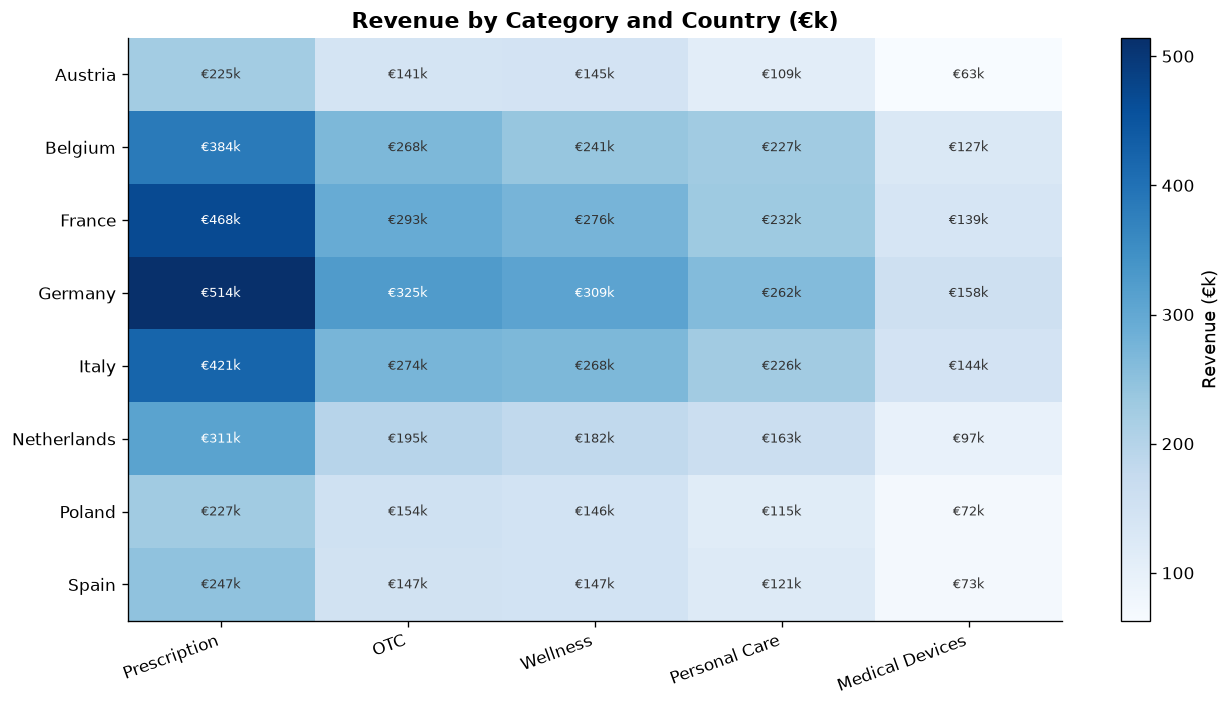

In [ ]:

fig, ax = plt.subplots(figsize=(11, 6))

import numpy as np

data    = pivot_rev.values / 1e3
rows    = pivot_rev.index.tolist()
cols    = pivot_rev.columns.tolist()

im = ax.imshow(data, cmap='Blues', aspect='auto')

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=20, ha='right')
ax.set_yticks(range(len(rows)))
ax.set_yticklabels(rows)
ax.set_title('Revenue by Category and Country (€k)', fontweight='bold')

# Annotate each cell
for i in range(len(rows)):
    for j in range(len(cols)):
        val = data[i, j]
        text_color = 'white' if val > data.max() * 0.6 else '#333'
        ax.text(j, i, f'€{val:.0f}k', ha='center', va='center',
                fontsize=8, color=text_color)

plt.colorbar(im, ax=ax, label='Revenue (€k)')
plt.tight_layout()
plt.savefig('outputs/03_category_by_country_heatmap.png', bbox_inches='tight')
plt.show()


In [13]:
query_cat_phtype = """
SELECT
    dp.pharmacytype,
    dpr.category,
    COUNT(DISTINCT dp.pharmacyid)                           AS pharmacy_count,
    COUNT(fs.salesid)                                       AS transactions,
    ROUND(SUM(fs.revenueeur), 2)                            AS total_revenue,
    ROUND(SUM(fs.revenueeur) / COUNT(DISTINCT dp.pharmacyid), 2) AS avg_revenue_per_pharmacy,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1) AS margin_pct
FROM fact_sales fs
JOIN dim_product dpr ON fs.productid  = dpr.productid
JOIN dim_pharmacy dp ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.pharmacytype, dpr.category
ORDER BY dp.pharmacytype, total_revenue DESC
"""

df_cat_phtype = run_query(query_cat_phtype)

# Pivot for grouped bar
pivot_phtype = df_cat_phtype.pivot(
    index='category', columns='pharmacytype', values='total_revenue'
).fillna(0)
pivot_phtype = pivot_phtype[['Urban', 'Suburban', 'Rural']]
pivot_phtype = pivot_phtype.reindex(['Prescription','OTC','Wellness','Personal Care','Medical Devices'])

print("── Revenue by category and pharmacy type ──")
print(pivot_phtype.round(0).to_string())



── Revenue by category and pharmacy type ──
pharmacytype         Urban   Suburban     Rural
category                                       
Prescription     1344372.0  1009509.0  443134.0
OTC               847437.0   649250.0  300643.0
Wellness          816949.0   616862.0  278646.0
Personal Care     687913.0   531164.0  235526.0
Medical Devices   428629.0   302511.0  141433.0


── Revenue by category and pharmacy type ──
pharmacytype         Urban   Suburban     Rural
category                                       
Prescription     1344372.0  1009509.0  443134.0
OTC               847437.0   649250.0  300643.0
Wellness          816949.0   616862.0  278646.0
Personal Care     687913.0   531164.0  235526.0
Medical Devices   428629.0   302511.0  141433.0


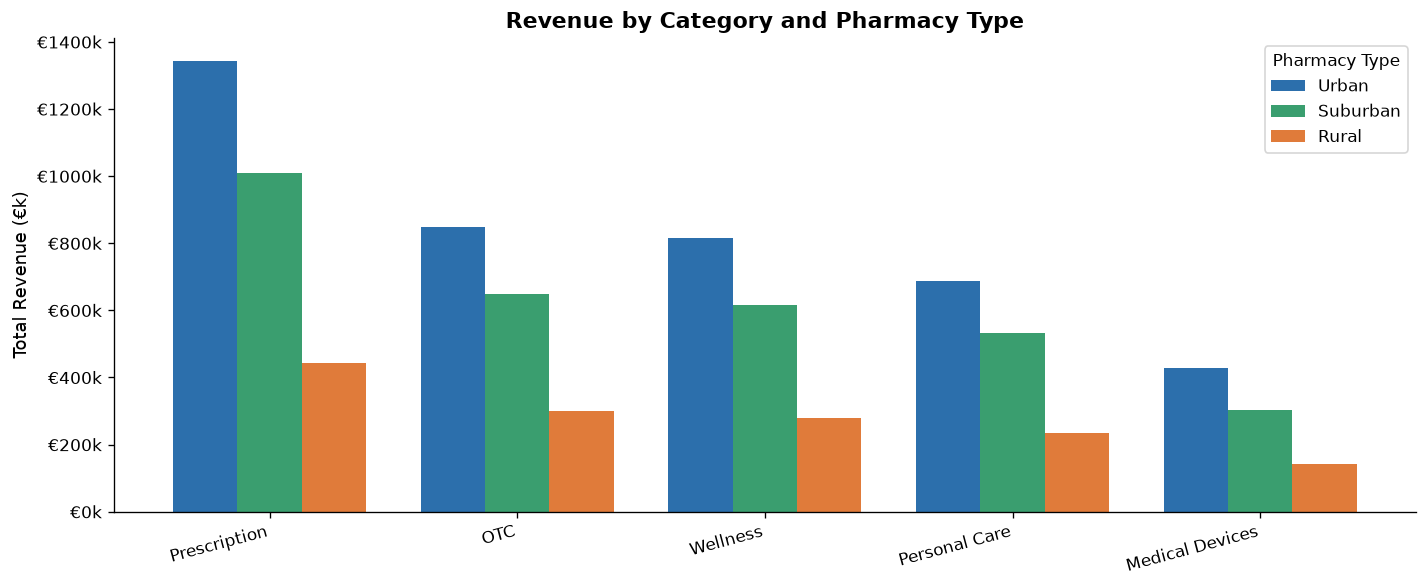

In [ ]:

fig, ax = plt.subplots(figsize=(12, 5))

x   = range(len(pivot_phtype.index))
w   = 0.26
ph_colors = ['#2C6FAC', '#3A9E6F', '#E07B3A']

for i, (col, color) in enumerate(zip(pivot_phtype.columns, ph_colors)):
    offset = (i - 1) * w
    bars = ax.bar(
        [xi + offset for xi in x],
        pivot_phtype[col] / 1e3,
        width=w, label=col, color=color
    )

ax.set_xticks(x)
ax.set_xticklabels(pivot_phtype.index, rotation=15, ha='right')
ax.set_ylabel('Total Revenue (€k)')
ax.set_title('Revenue by Category and Pharmacy Type', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))
ax.legend(title='Pharmacy Type')

plt.tight_layout()
plt.savefig('outputs/04_category_by_pharmacy_type.png', bbox_inches='tight')
plt.show()

In [14]:
query_top_margin_products = """
SELECT
    dpr.productid,
    dpr.productname,
    dpr.category,
    dpr.brand,
    COUNT(fs.salesid)                                       AS transactions,
    ROUND(SUM(fs.revenueeur), 2)                            AS total_revenue,
    ROUND(SUM(fs.margineur), 2)                             AS total_margin,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1) AS margin_pct
FROM fact_sales fs
JOIN dim_product dpr ON fs.productid = dpr.productid
GROUP BY dpr.productid, dpr.productname, dpr.category, dpr.brand
HAVING COUNT(fs.salesid) >= 100
ORDER BY margin_pct DESC
LIMIT 10
"""

df_top_margin = run_query(query_top_margin_products)

print("── Top 10 products by margin % (min 100 transactions) ──")
print(df_top_margin.to_string(index=False))


── Top 10 products by margin % (min 100 transactions) ──
productid                    productname      category      brand  transactions  total_revenue  total_margin  margin_pct
   PR0153      ZenHealth Probiotic Daily      Wellness  ZenHealth           290       29797.40      11569.87        38.8
   PR0004       DermaSoft Shampoo Repair Personal Care  DermaSoft           239       31711.85      12217.60        38.5
   PR0167     DermaSoft Sunscreen Bright Personal Care  DermaSoft           174       13665.73       5242.33        38.4
   PR0147          NatureFit Omega-3 Max      Wellness  NatureFit           334       39147.08      14964.31        38.2
   PR0212  FreshLine Mouthwash Sensitive Personal Care  FreshLine           250        5196.86       1984.07        38.2
   PR0205 BioBalance Multivitamin Active      Wellness BioBalance           344       52851.84      20018.12        37.9
   PR0090       CleanWave Shampoo Bright Personal Care  CleanWave           285       34140.39  

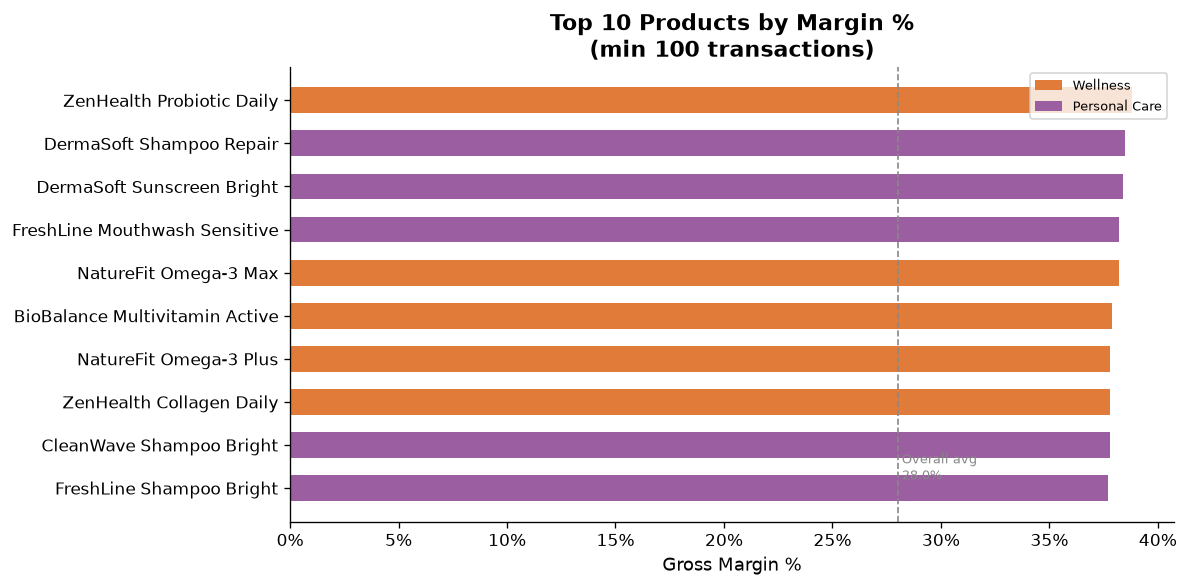

In [16]:

bar_colors = [CATEGORY_COLORS[c] for c in df_top_margin.sort_values('margin_pct')['category']]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    df_top_margin.sort_values('margin_pct')['productname'].str[:35],
    df_top_margin.sort_values('margin_pct')['margin_pct'],
    color=bar_colors, height=0.6
)
ax.set_xlabel('Gross Margin %')
ax.set_title('Top 10 Products by Margin %\n(min 100 transactions)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.axvline(x=28.0, color='#888', linewidth=1, linestyle='--')
ax.text(28.2, 0.2, 'Overall avg\n28.0%', fontsize=8, color='#888')

legend_elements = [Patch(facecolor=v, label=k) for k, v in CATEGORY_COLORS.items()
                   if k in df_top_margin['category'].values]
ax.legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.savefig('outputs/05_top_products_margin.png', bbox_inches='tight')
plt.show()

In [20]:
# Category summary — feeds Revenue by Category dashboard view
df_cat.to_csv('../../data/processed/category_revenue_margin.csv', index=False)

# Brand summary
df_brands.to_csv('../../data/processed/brand_revenue_margin.csv', index=False)

# Category x Country
df_cat_country.to_csv('../../data/processed/category_by_country.csv', index=False)

# Category x Pharmacy Type
df_cat_phtype.to_csv('../../data/processed/category_by_pharmacy_type.csv', index=False)

# Top margin products
df_top_margin.to_csv('../../data/processed/top_margin_products.csv', index=False)

print("All CSVs exported to data/processed/")
print()
print("Files created:")
print("  category_revenue_margin.csv")
print("  brand_revenue_margin.csv")
print("  category_by_country.csv")
print("  category_by_pharmacy_type.csv")
print("  top_margin_products.csv")

All CSVs exported to data/processed/

Files created:
  category_revenue_margin.csv
  brand_revenue_margin.csv
  category_by_country.csv
  category_by_pharmacy_type.csv
  top_margin_products.csv


In [21]:
summary = """
MODULE 1 — REVENUE & MARGIN ANALYSIS
=====================================

OVERALL KPIs
------------
Total Revenue:       €8,633,977
Total Margin:        €2,421,141
Overall Margin %:    28.0%
Total Units Sold:    445,793
Total Transactions:  62,139

CATEGORY FINDINGS
-----------------
1. Prescription leads revenue with a 32.4% share (€2.80M) but has the
   lowest margin % at 21.9% — 6 points below the overall average.

2. Wellness and Personal Care are the margin leaders at 33.6% and 33.5%
   respectively — both above the overall average despite lower revenue rank.

3. OTC is the volume leader — 19,412 transactions and 9.15 avg units per
   transaction. Margin % of 29.4% is above average.

4. Medical Devices has the highest revenue per unit (€62.79) but is the
   smallest category by transaction count (6,051).

5. Revenue rank ≠ margin rank — Prescription ranks 1st on revenue but
   last on margin %. Wellness ranks 3rd on revenue but 1st on margin %.

BRAND FINDINGS
--------------
- AntiBioX is the top revenue brand (€726k, 8.4% share) — Prescription
- ZenHealth leads margin % at 35.3% among brands with 500+ transactions — Wellness
- All top-margin brands belong to Wellness or Personal Care
- Prescription brands cluster at 20–24% margin — structurally lower

GEOGRAPHIC FINDINGS
-------------------
- Category mix is proportional across all 8 countries
- No country shows unusual category preference
- Prescription leads revenue in every single country

PHARMACY TYPE FINDINGS
----------------------
- Category ranking (Prescription > OTC > Wellness > Personal Care > Medical Devices)
  holds consistent across Urban, Suburban, and Rural pharmacy types

CHARTS SAVED
------------
  outputs/01_category_revenue_margin.png
  outputs/02_brand_performance.png
  outputs/03_category_by_country_heatmap.png
  outputs/04_category_by_pharmacy_type.png
  outputs/05_top_products_margin.png

CSVs EXPORTED
-------------
  data/processed/category_revenue_margin.csv
  data/processed/brand_revenue_margin.csv
  data/processed/category_by_country.csv
  data/processed/category_by_pharmacy_type.csv
  data/processed/top_margin_products.csv
"""

print(summary)


MODULE 1 — REVENUE & MARGIN ANALYSIS

OVERALL KPIs
------------
Total Revenue:       €8,633,977
Total Margin:        €2,421,141
Overall Margin %:    28.0%
Total Units Sold:    445,793
Total Transactions:  62,139

CATEGORY FINDINGS
-----------------
1. Prescription leads revenue with a 32.4% share (€2.80M) but has the
   lowest margin % at 21.9% — 6 points below the overall average.

2. Wellness and Personal Care are the margin leaders at 33.6% and 33.5%
   respectively — both above the overall average despite lower revenue rank.

3. OTC is the volume leader — 19,412 transactions and 9.15 avg units per
   transaction. Margin % of 29.4% is above average.

4. Medical Devices has the highest revenue per unit (€62.79) but is the
   smallest category by transaction count (6,051).

5. Revenue rank ≠ margin rank — Prescription ranks 1st on revenue but
   last on margin %. Wellness ranks 3rd on revenue but 1st on margin %.

BRAND FINDINGS
--------------
- AntiBioX is the top revenue brand (€72